# Limpieza

## Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import numpy as np

In [2]:
# Configuramos que se muestren todas las columnas de nuestros dataframes
pd.set_option('display.max_columns', None)

## Carga de Datos


In [3]:
df_bank = pd.read_csv('files/output/df_bank_ap.csv')

In [4]:
df_bank.sample(2)

,AGE,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED,Y,DATE,ID
11145,52.0,services,divorced,high-school,no,yes,no,telephone,83,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,no,2015-05-02,1dbf52bb-57d3-48f3-807d-c707ae3c9b92
16176,33.0,services,single,high-school,no data,yes,no,cellular,560,2,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,yes,2015-09-26,7e864166-0097-48f4-a608-6b6ac78dfeb9


In [5]:
df_customer = pd.read_csv('files/output/df_customer_ap.csv')

In [6]:
df_customer.sample(2)

,INCOME,KIDHOME,TEENHOME,DTCUSTOMER,NUMWEBVISITSMONTH,ID
34801,72275,0,2,2014-05-10,20,4d0819e3-0d5c-4401-af72-7158d8a736b3
16622,69969,2,1,2012-06-12,17,c0f7ec10-4945-4747-aa03-1fbc7b51c184


## Dataset 1:  **bank-additional**

### Gestión de Nulos

Recordamos las columnas con valores nulos que tenemos en el dataframe tras las transformaciones iniciales numéricas, dado que para las variables categóricas ya se tomó la decisión de constuir los valores nulos como una categotía propia 'no data' para identificarlos claramente durante el análisis.

In [7]:
# importamos la funcion de analisis de nulos que gemos creado

from scr.explore_utils import null_analysis

In [8]:
nulos = null_analysis(df_bank).sort_values(by= 'NULL_PERCENT',ascending=False)

In [9]:
nulos[nulos['NULL_PERCENT'] > 0]

,COLUMN_NAME,NON_NULL_COUNT,NULL_COUNT,NULL_PERCENT,DTYPE
16,EURIBOR3M,33744,9256,21.53,float64
0,AGE,37880,5120,11.91,float64
14,CONSPRICEIDX,42529,471,1.10,float64
19,DATE,42752,248,0.58,object


#### Columna EURIBOR3M (float64, 21.53% nulos)  DATE 0.58

No podemos eliminar sin más las filas de valores nulos dado que al suponer más del 20% perderíamos una  

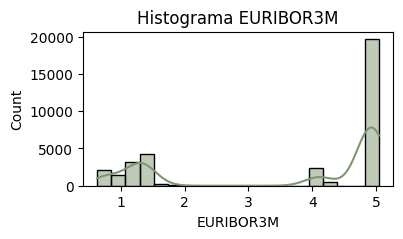

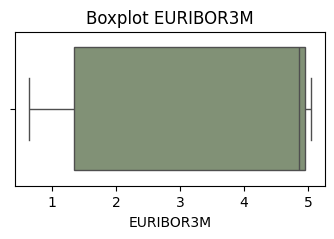

In [10]:
plt.figure(figsize=(4,2))
sns.histplot(df_bank['EURIBOR3M'].dropna(), kde=True, color='#809671')
plt.title("Histograma EURIBOR3M")
plt.show()

plt.figure(figsize=(4,2))
sns.boxplot(x=df_bank['EURIBOR3M'], color='#809671')
plt.title("Boxplot EURIBOR3M")
plt.show()


In [11]:
skewness = df_bank['EURIBOR3M'].dropna().skew()
kurtosis = df_bank['EURIBOR3M'].dropna().kurt()

print("Asimetría (skewness):", skewness)
print("Curtosis:", kurtosis)

Asimetría (skewness): -0.7039151102503337
Curtosis: -1.4144370099465358


Debido a la distrubución asimétrica, no resulta adecuado emplear métodos de imputación basados en la media o la mediana para la variable EURIBOR3M. 

Para distribuciones no normales como en este caso, es preferible considerar métodos de imputación basados en modelos predictivos, para los que primero habrá que comprobar si existen correlaciones significativas con otras columnas que puedan servir para realizar dichas predicciones.

EURIBOR3M       1.000000
EMPVARRATE      0.972361
NREMPLOYED      0.945283
CONSPRICEIDX    0.684790
PDAYS           0.302078
CONSCONFIDX     0.273606
CAMPAIGN        0.137343
AGE             0.010250
DURATION       -0.034426
PREVIOUS       -0.459629
Name: EURIBOR3M, dtype: float64


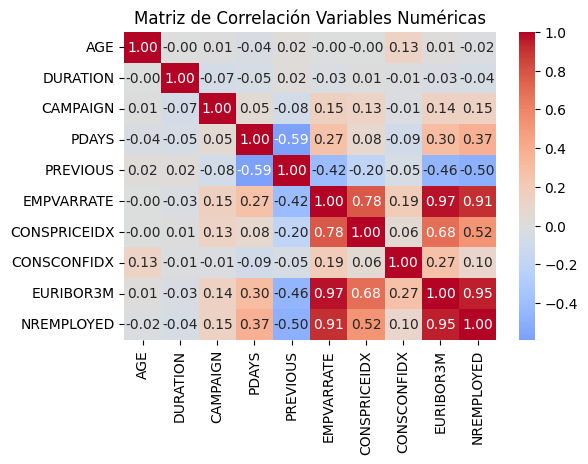

In [12]:
# Seleccionamos solo columnas numéricas
numeric_cols = df_bank.select_dtypes(include=['float64', 'int64']).columns

# Calcula la matriz de correlación
corr_matrix = df_bank[numeric_cols].corr()

# Muestramos las correlaciones de EURIBOR3M con otras numéricas
print(corr_matrix['EURIBOR3M'].sort_values(ascending=False))

# Visualizamos la matriz completa en un heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matriz de Correlación Variables Numéricas")
plt.show()

La matriz de correlación muestra que EURIBOR3M tiene una correlación alta con varias variables numéricas:
- `Cons.price.idx`: Correlación de 0.97 (muy fuerte), lo que indica que los valores de EURIBOR3M se relacionan estrechamente con el índice de precios al consumidor.
- `Emp.var.rate`: Correlación de 0.62 (moderada-fuerte), señalando una relación significativa entre la tasa de variación en el empleo y EURIBOR3M.
- `Nr.employed`: Correlación de 0.95 (muy fuerte), sugiere también una relación directa entre EURIBOR3M y el número de empleados en el periodo.

Estos resultados justifican el uso de KNNImputer debido a que la columna EURIBOR3M tiene una correlación fuerte con varias otras variables numéricas del dataset, dado que nos permite emplear la información de las variables relacionadas para imputar de una forma más realista y menos sesgada que métodos simples como la media o la mediana.

In [13]:
# Elegimos las columnas correlacionadas y la variable a imputar
cols_for_imputation = ['EURIBOR3M', 'CONSPRICEIDX', 'NREMPLOYED', 'EMPVARRATE']

# Seleccionamos solo las columnas necesarias
df_knn = df_bank[cols_for_imputation]

# Creamos el imputer
imputer = KNNImputer(n_neighbors=5)

# Aplicamos KNNImputer 
df_knn_imputed = pd.DataFrame(imputer.fit_transform(df_knn), columns=cols_for_imputation)

# Asignamos los valores imputados de EURIBOR3M al dataframe original 
df_bank['EURIBOR3M'] = df_knn_imputed['EURIBOR3M']

In [14]:
# Verificamos que no queden nulos
print(df_bank['EURIBOR3M'].isnull().sum())

0


#### Columna AGE  (float64, 11.91% nulos)

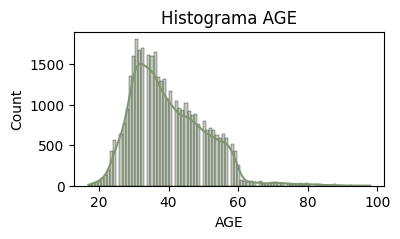

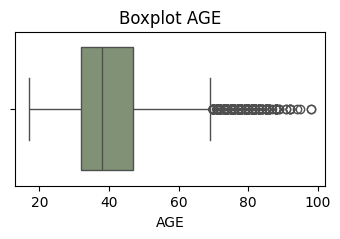

In [15]:
plt.figure(figsize=(4,2))
sns.histplot(df_bank['AGE'].dropna(), kde=True, color='#809671')
plt.title("Histograma AGE")
plt.show()

plt.figure(figsize=(4,2))
sns.boxplot(x=df_bank['AGE'], color='#809671')
plt.title("Boxplot AGE")
plt.show()

Para la columna AGE, aunque la imputación por mediana es ampliamente usada por su robustez frente a outliers y distribuciones no normales, en este dataset el elevado porcentaje de valores nulos distorsiona gravemente la distribución. Esto se traduce en un pico artificial que dificulta cualquier interpretación posterior. 

Al no existir una correlación fuerte con otras variables numéricas del conjunto, tampoco resulta adecuado emplear métodos multivariantes como KNNImputer. 

Finalmente, se opta por una estrategia combinada que maximiza la coherencia y la representatividad de los datos:
1. Primero, se imputa la mediana de AGE dentro de cada subgrupo definido por las variables sociodemográficas relevantes (JOB, EDUCATION, MARITAL, HOUSING, LOAN). Esto permite asignar un valor característico y específico a cada perfil, evitando que la imputación sea arbitraria y reduciendo el sesgo que genera la mediana global en distribuciones no normales.
2. Para los casos donde algún subgrupo no contiene valores para AGE y la mediana no puede calcularse, se imputa la mediana global como último recurso. De esta forma, se garantiza la ausencia total de nulos en la columna manteniendo la máxima riqueza informativa posible.

Esta estrategia es más robusta que la eliminación directa de registros nulos, ya que preserva la muestra del dataset y crea imputaciones que reflejan mejor la estructura sociodemográfica original del conjunto de datos.

In [16]:
df_bank['AGE'] = df_bank.groupby(['JOB','EDUCATION','MARITAL', 'HOUSING','LOAN'])['AGE'].transform(lambda x: x.fillna(x.median()))
df_bank['AGE'] = df_bank['AGE'].fillna(df_bank['AGE'].median())

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis

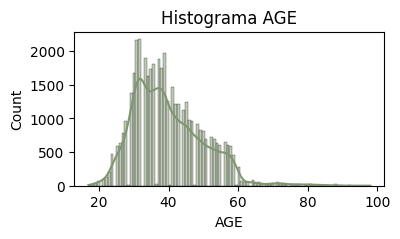

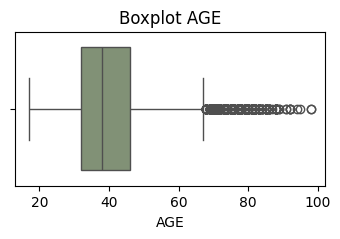

In [17]:
# Comprobamos que tras la  gestion de nulos, la distribución no ha sufrido alteraciones tan notorias como con el resto de opciones.

plt.figure(figsize=(4,2))
sns.histplot(df_bank['AGE'].dropna(), kde=True, color='#809671')
plt.title("Histograma AGE")
plt.show()

plt.figure(figsize=(4,2))
sns.boxplot(x=df_bank['AGE'], color='#809671')
plt.title("Boxplot AGE")
plt.show()

#### Columna CONSPRICEIDX (float64, 1.10% nulos) 

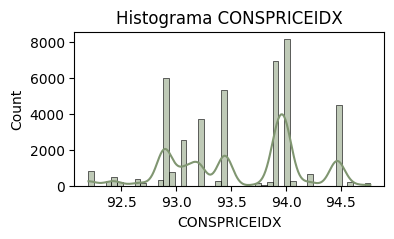

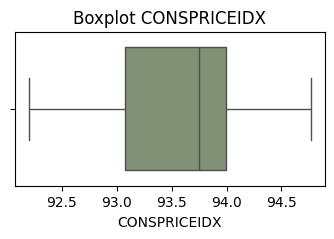

In [18]:
plt.figure(figsize=(4,2))
sns.histplot(df_bank['CONSPRICEIDX'].dropna(), kde=True, color='#809671')
plt.title("Histograma CONSPRICEIDX")
plt.show()

plt.figure(figsize=(4,2))
sns.boxplot(x=df_bank['CONSPRICEIDX'], color='#809671')
plt.title("Boxplot CONSPRICEIDX")
plt.show()

In [19]:
df_bank['CONSPRICEIDX'] = df_bank['CONSPRICEIDX'].fillna(df_bank['CONSPRICEIDX'].median())


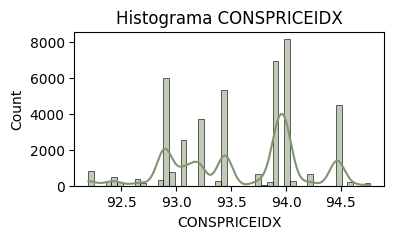

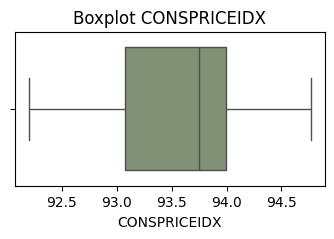

In [20]:
plt.figure(figsize=(4,2))
sns.histplot(df_bank['CONSPRICEIDX'].dropna(), kde=True, color='#809671')
plt.title("Histograma CONSPRICEIDX")
plt.show()

plt.figure(figsize=(4,2))
sns.boxplot(x=df_bank['CONSPRICEIDX'], color='#809671')
plt.title("Boxplot CONSPRICEIDX")
plt.show()

En el caso de la variable CONSPRICEIDX (índice de precios al consumidor), los valores nulos representan solo el 1.1% del total. Se ha elegido la imputación por mediana porque, dada la baja proporción de nulos y la naturaleza multimodal pero acotada de la variable, este método no modifica sustancialmente la distribución original y permite mantener la coherencia estadística del análisis exploratorio.

#### Columna DATE (float64,  0.58% nulos) 

Dado que los valores nulos en la columna DATE representan menos del 1% del total y la fecha es un dato clave para el análisis temporal, se han eliminado esos registros. Esta decisión asegura la máxima integridad en el tratamiento cronológico sin afectar de forma significativa la representatividad del conjunto de datos.

Posteriomente se transforma a tipo datetime, para su correcto manejo posterior.

In [21]:
df_bank = df_bank.dropna(subset=['DATE'])

In [22]:
df_bank['DATE'] = pd.to_datetime(df_bank['DATE'])

In [32]:
df_bank["DATE"].dtypes

dtype('<M8[ns]')

In [23]:
df_bank.sample(1)

,AGE,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED,Y,DATE,ID
36417,51.0,unemployed,married,basic-6y,no,yes,no,cellular,262,2,999,0,nonexistent,-2.9,92.963,-40.8,1.26,5076.2,yes,2015-01-12,17aa8859-a804-4463-b26f-e7402f9e7bfd


### Transformaciones Complementarias

Se crea una nueva columna categórica de rangos de edad a partir de la variable numérica original “AGE”. 

Esta transformación facilita la visualización, el análisis comparativo entre grupos y la inclusión de la variable edad en modelos que requieren variables categóricas. Además, reduce el impacto de valores extremos, evita la suposición de linearidad entre edad y la respuesta de interés, y es especialmente útil para identificar tendencias demográficas.

In [24]:
bins = [15, 25, 35, 45, 55, 65, 100]
labels = ['15-24','25-34','35-44','45-54','55-64','65+']
df_bank['AGE_CAT'] = pd.cut(df_bank['AGE'], bins=bins, labels=labels, right=False)

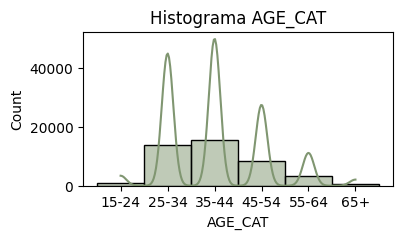

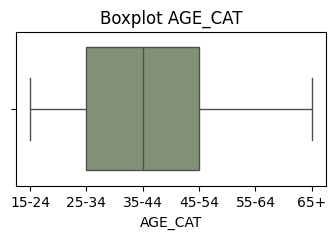

In [25]:
plt.figure(figsize=(4,2))
sns.histplot(df_bank['AGE_CAT'].dropna(), kde=True, color='#809671')
plt.title("Histograma AGE_CAT")
plt.show()

plt.figure(figsize=(4,2))
sns.boxplot(x=df_bank['AGE_CAT'], color='#809671')
plt.title("Boxplot AGE_CAT")
plt.show()

Para facilitar el análisis y la interpretación de los niveles educativos, se agrupan las categorías relacionadas con la educación obligatoria ("basic-4y", "basic-6y" y "basic-9y") en una nueva categoría común denominada "basic". Esta operación se realiza mediante una columna adicional, preservando el valor original de la variable.

La decisión responde a criterios de simplicidad y relevancia sociodemográfica: estos tres niveles representan etapas similares dentro del sistema educativo y suelen asociarse a perfiles afines en estudios de mercado y análisis social. Agruparlos mejora la robustez estadística y permite comparativas más claras entre grandes bloques educativos

In [26]:
df_bank['EDUCATION_GROUPED'] = df_bank['EDUCATION'].replace(
    {'basic-4y': 'basic',
     'basic-6y': 'basic',
     'basic-9y': 'basic'}
)

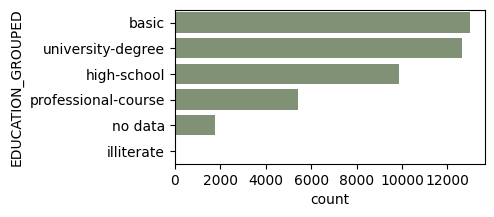

In [27]:
order = df_bank['EDUCATION_GROUPED'].value_counts().index

plt.figure(figsize=(4,2))

ax = sns.countplot(df_bank['EDUCATION_GROUPED'], order = order, color='#809671')

plt.show()

### Tratamiento de PDAYS (Días desde el último contacto)

La variable `PDAYS` contiene el valor 999 para indicar que el cliente no fue contactado previamente. Esto distorsiona el análisis numérico. Se separa esta información en dos variables:
- `WAS_CONTACTED`: Categórica que indica si hubo contacto previo.
- `DAYS_SINCE_CONTACT`: Variable numérica con los días reales de espera (999 se convierte en NaN).

> Justificación de Nulos en DAYS_SINCE_CONTACT:A diferencia de otras variables donde se imputaron valores (ej. `AGE`), en `DAYS_SINCE_CONTACT` mantenemos los `NaN` para los clientes no contactados (999). Esto se debe a que son **nulos estructurales** (el dato no existe porque el evento no ocurrió). Imputarlos introduciría ruido; dejarlos como `NaN` permite calcular estadísticas limpias solo sobre el subgrupo de clientes recurrentes.

In [28]:
# Crear variable categórica
df_bank['WAS_CONTACTED'] = df_bank['PDAYS'].ne(999)  # True/False
df_bank['WAS_CONTACTED'] = df_bank['WAS_CONTACTED'].map({True: 'yes', False: 'no'})
df_bank['WAS_CONTACTED'] = df_bank['WAS_CONTACTED'].astype('category')

# Crear variable numérica limpia (999 -> NaN)
df_bank['DAYS_SINCE_CONTACT'] = df_bank['PDAYS'].replace(999, np.nan)

# Verificamos
print(df_bank[['PDAYS', 'WAS_CONTACTED', 'DAYS_SINCE_CONTACT']].head())

   PDAYS WAS_CONTACTED  DAYS_SINCE_CONTACT
0    999            no                 NaN
1    999            no                 NaN
2    999            no                 NaN
3    999            no                 NaN
4    999            no                 NaN


In [29]:
df_bank[["WAS_CONTACTED", "DAYS_SINCE_CONTACT"]][df_bank.PDAYS != 999].sample(2)

,WAS_CONTACTED,DAYS_SINCE_CONTACT
40476,yes,6.0
39284,yes,6.0


## Resumen de la Gestión Total de Limpieza de Datos

Este resumen abarca la limpieza completa realizada en la combinación de ambos ficheros, incluyendo tanto el análisis preliminar (`01-analisis-preeliminar.ipynb`) como las transformaciones aplicadas en este fichero de limpieza (`02-limpieza.ipynb`).

### Fichero 1: bank-additional

- Se nombraron columnas para facilitar su uso, corrigiendo formatos y eliminando caracteres no deseados.
- En las columnas categóricas con valores nulos, estos se sustituyeron por una categoría explícita “no data” para mantener la integridad del dataset y facilitar el análisis.
- Se identificaron columnas numéricas con valores nulos y se aplicaron imputaciones específicas según la naturaleza y proporción de los datos:
  - **AGE:** Imputación por la mediana dentro de subgrupos sociodemográficos, respaldada por la mediana global en casos necesarios.
  - **EURIBOR3M:** Aplicación de KNNImputer para aprovechar correlaciones complejas.
  - **CONSPRICEIDX:** Imputación simple usando la mediana global.
- La columna **DATE**, con bajo porcentaje de valores nulos, tuvo sus registros con NA eliminados para preservar analíticas temporales y se transformó en un formato de fecha.

#### Transformaciones adicionales

- **Categorización por rangos de edad:** Se creó una nueva columna categórica agrupando edades en intervalos relevantes para facilitar el análisis poblacional y mejorar la segmentación sociodemográfica.
- **Agrupación de educación básica:** Se agregaron los subniveles “basic-4y”, “basic-6y” y “basic-9y” en una nueva columna “basic", permitiendo comparativas más claras y robustas entre grandes bloques educativos.
- **Días desde el último contacto:** Se creó una variable binaria que indica si el cliente fue contactado (PDAYS != 999) y una variable numérica que indica el número de días desde el último contacto.


### Fichero 2: bank-additional-clean

- No se detectaron valores nulos.
- Se realizó validación de formatos y tipos de datos, y revisión de datos duplicados, dejando el fichero listo para análisis.

---

### Conclusión General

La limpieza total en la combinación de ambos ficheros fue realizada con métodos adaptados al contexto individual de cada variable y conjunto de datos.  
Se garantizó preservación de información, coherencia estadística y claridad en la documentación de las transformaciones, incluyendo categorizaciones y agrupaciones relevantes, para análisis fiables y replicables.


### Guardar CSV con ajustes preeliminares

In [33]:
# Guardamos el dataframe 1
df_bank.to_csv('files/output/df_bank_clean.csv', index=False, encoding='utf-8-sig')

In [34]:
# Guardamos el dataframe 2
df_customer.to_csv('files/output/df_customer_clean.csv', index=False, encoding='utf-8-sig')